# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** SHREEHARI KULKARNI  
**Student ID:** 2025AC05644
**Date:** 06/06/2026

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.drop_duplicates(inplace = True)

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data = pd.get_dummies(data, drop_first = True)

In [10]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
# TODO: Load your dataset
# Example: data = pd.read_csv('your_dataset.csv')
data = pd.read_csv('diabetes.csv')
# data.head()

data.shape
# Dataset information (TODO: Fill these)
dataset_name = "Pima Indians Diabetes Database"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "Kaggle (Pima Indians Diabetes Database, originally from UCI Machine Learning Repository)"  # e.g., "UCI ML Repository"
n_samples = 768     # Total number of rows
n_features = 8     # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
Prediciting diabetes or not, this is essential for early detection of diabetes in a patient
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "recall"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """I chose recall because in medical diagnosis,
false negatives (missing diabetes) are more costly than false positives."
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
print(f'Metric Justification: {metric_justification}')

Dataset: Pima Indians Diabetes Database
Source: Kaggle (Pima Indians Diabetes Database, originally from UCI Machine Learning Repository)
Samples: 768, Features: 8
Problem Type: binary_classification
Primary Metric: recall
Metric Justification: I chose recall because in medical diagnosis,
false negatives (missing diabetes) are more costly than false positives."



## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [12]:
# TODO: Preprocess your data
# 1. Separate features (X) and target (y)
# 2. Handle missing values if any
# 3. Encode categorical variables

# Example:
data.shape
data.info()
data.isna().sum()

data.duplicated().sum()

data.drop_duplicates(inplace = True)

data.duplicated().sum()

# Handling outliers
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# remove outliers 
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]
data.head()


X = data.drop('Outcome', axis=1)
y = data['Outcome']






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
# TODO: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# TODO: Feature scaling
scaler = StandardScaler()
columns_to_scale = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.fit_transform(X_test[columns_to_scale])


no_of_train_samples = 0.80 * data.shape[0]
print(no_of_train_samples)
# Fill these after preprocessing
train_samples = int(0.80 * data.shape[0])       # Number of training samples
test_samples = int(0.20  * data.shape[0])       # Number of test samples
train_test_ratio = 0.80  # e80.g., 0.8 for 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

511.20000000000005
Train samples: 511
Test samples: 127
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [14]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=10000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def LogLoss(self, y, yhat):
        return -(y * np.log(yhat)) - ((1 - y) * np.log(1 - yhat))
        
    def cost_func(self, y, yhat):
        m = len(y)
        cost = np.sum(self.LogLoss(y, yhat)) / m
        return cost     

    
    def fit(self, X, y):
        """
        TODO: Implement gradient descent training
        
        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history
        
        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape
        
        # TODO: Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # TODO: Implement gradient descent loop
        for i in range(self.n_iterations):
            z = np.dot(X,self.weights) + self.bias
            yhat = self.sigmoid(z)

            loss_cost = self.cost_func(y,yhat)
            self.loss_history.append(loss_cost)

            dw = (1 / n_samples) * np.dot(X.T, (yhat -y))
            db = (1 / n_samples) * np.sum(yhat - y)

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 1. Forward pass: y_pred = ...
            # 2. Compute loss
            # 3. Compute gradients: dw = ..., db = ...
            # 4. Update: self.weights -= self.lr * dw
            # 5. self.loss_history.append(loss)
        
        return self
    
    def predict(self, X):
        """
        TODO: Implement prediction
        
        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        z = np.dot(X, self.weights) + self.bias
        yhat = self.sigmoid(z)
        pred_class = [1 if p>= 0.5 else 0 for p in yhat]
        return np.array(pred_class)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [15]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=10000)
baseline_model.fit(X_train, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]} to {baseline_model.loss_history[-1]}")

Training baseline model...
✓ Baseline training completed in 9.74s
✓ Loss decreased from 0.6931471805599453 to 0.45377490910760476


In [16]:
print("Bias:", baseline_model.bias)
print("Predictions:", baseline_predictions)
# print("Accuracy:", acc)

Bias: -1.4793223944662373
Predictions: [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 1
 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [17]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=10000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}
        self.z = {}
    
    def initialize_parameters(self):
        """
        TODO: Initialize weights and biases for all layers
        
        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)
        
        Store in self.parameters dictionary
        """
        
        np.random.seed(42)
        
        for l in range(1, len(self.architecture)):
            # TODO: Initialize weights and biases
            # self.parameters[f'W{l}'] = ...
            # self.parameters[f'b{l}'] = ...

            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l-1], self.architecture[l]) * np.sqrt(1/self.architecture[l-1])
            self.parameters[f'b{l}'] = np.zeros((1, self.architecture[l]))

        # print(self.parameters)

    
    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)
    
    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    
    def forward_propagation(self, X):
        """
        TODO: Implement forward pass through all layers
        
        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])
        
        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        self.cache['A0'] = X
        
        # TODO: Implement forward pass
        # for l in range(1, len(self.architecture)):
        #     ...
        n = len(self.architecture)
        # print(n)
        for l in range(1,len(self.architecture)):
            self.z[f'z{l}'] = np.dot(self.cache[f'A{l-1}'],self.parameters[f'W{l}']) + self.parameters[f'b{l}']
            if l+1 == n:
                self.cache[f'A{l}'] = self.sigmoid(self.z[f'z{l}'])
            else:
                self.cache[f'A{l}'] = self.relu(self.z[f'z{l}'])

        value_to_return = n - 1
        # print(value_to_return)
        # print(self.cache)

        return self.cache[f'A{value_to_return}']
        
    
    def backward_propagation(self, X, y):
        """
        TODO: Implement backward pass to compute gradients
        
        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m
        
        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        # print("A2 shape:", self.cache["A2"].shape)
        # print("y shape :", y.shape)
        dZ2 = self.cache["A2"] - y
        dW2 = (1/m) * np.dot(self.cache["A1"].T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        grads['Layer-2'] = [dZ2,dW2,db2]

        dA1 = np.dot(dZ2,self.parameters['W2'].T)
        dZ1 = dA1 * self.relu_derivative(self.z['z1'])
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        grads['Layer-1'] = [dZ1,dW1,db1]
        
                     
        
        # TODO: Implement backward pass
        # Start with output layer gradient
        # Then propagate backwards through hidden layers
         # Replace with your implementation
        
        return grads
    
    def update_parameters(self, grads):
        """
        TODO: Update weights and biases using gradients
        
        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        # TODO: Implement parameter updates
        self.parameters['W1'] -= self.lr * grads['Layer-1'][1]
        self.parameters['b1'] -= self.lr * grads['Layer-1'][2]

        self.parameters['W2'] -= self.lr * grads['Layer-2'][1]
        self.parameters['b2'] -= self.lr * grads['Layer-2'][2]
    
    def compute_loss(self, y_pred, y_true):
        """
        TODO: Compute loss
        
        For regression: MSE
        For classification: Cross-entropy
        """
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1-epsilon)

        loss = -np.mean(
            y_true*np.log(y_pred) +
            (1-y_true)*np.log(1-y_pred)
        )

        return loss
        pass  # Replace with your implementation
    
    def fit(self, X, y):
        """
        TODO: Implement training loop
        
        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss
        
        Must populate self.loss_history!
        """
        self.initialize_parameters()
        y = np.array(y).reshape(-1, 1)
        
        for i in range(self.n_iterations):
            # TODO: Training loop
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
            self.loss_history.append(loss)
            
            
        
        return self
    
    def predict(self, X):
        """
        TODO: Implement prediction
        
        Use forward_propagation and apply appropriate thresholding
        """
        probs = self.forward_propagation(X)

        return (probs >= 0.5).astype(int)
        pass  # Replace with your implementation

print("✓ MLP class defined")

✓ MLP class defined


In [18]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
722,1,1.004207,-0.393266,0.539350,0.733503,-0.428419,0.349,0.804214
213,0,0.694708,-0.656646,0.344528,0.770607,1.616003,0.431,-0.803165
343,5,0.075709,1.187015,-1.343926,-0.837214,0.401647,0.290,0.000524
306,10,1.416873,-0.393266,0.149706,0.795343,-1.012540,0.326,1.250708
304,3,1.038596,0.309081,-1.343926,-0.837214,-1.704262,0.207,0.357720
...,...,...,...,...,...,...,...,...
91,4,0.110098,0.660254,-0.369818,1.339528,-0.013386,0.443,0.089823
132,3,1.726372,-0.744440,1.058874,1.945553,0.370904,0.356,-0.267372
328,2,-0.612067,1.187015,0.993933,0.646928,2.061779,0.127,-0.892464
527,3,-0.130624,0.133494,-0.369818,0.461411,-0.889567,0.107,-0.803165


In [19]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# TODO: Define your architecture and train MLP
mlp_architecture = [8,16,1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=100000)
mlp_model.fit(X_train.to_numpy(), y_train)

# TODO: Make predictions
mlp_predictions = mlp_model.predict(X_test)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 32.91s
✓ Loss decreased from 0.7549 to 0.3217


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [21]:
def calculate_metrics(y_true, y_pred, problem_type,model_type):
    """
    TODO: Calculate appropriate metrics based on problem type
    
    For regression: MSE, RMSE, MAE, R²
    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}
    print(type(y_pred))
    print(type(y_test))
    
    if problem_type == "regression":
        # TODO: Calculate regression metrics
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # TODO: Calculate classification metrics
        metrics[f'{model_type}'] = {'Accuracy': accuracy_score(y_test, y_pred),'Recall': recall_score(y_test, y_pred),'Precision': precision_score(y_test, y_pred),'F1 Score': f1_score(y_test, y_pred)}



    
    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions,"binary_classification","baseline_model")
mlp_metrics = calculate_metrics(y_test, mlp_predictions, "binary_classification","mlp")

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
Baseline Model Performance:
{'baseline_model': {'Accuracy': 0.796875, 'Recall': 0.4722222222222222, 'Precision': 0.7083333333333334, 'F1 Score': 0.5666666666666667}}

MLP Model Performance:
{'mlp': {'Accuracy': 0.78125, 'Recall': 0.6111111111111112, 'Precision': 0.6111111111111112, 'F1 Score': 0.6111111111111112}}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

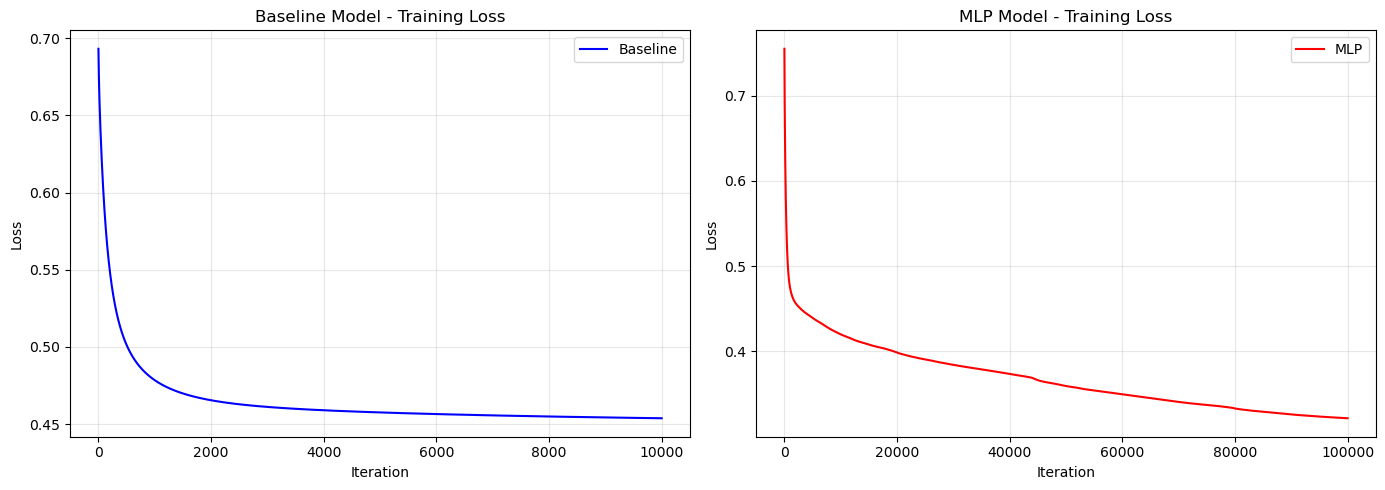

In [22]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

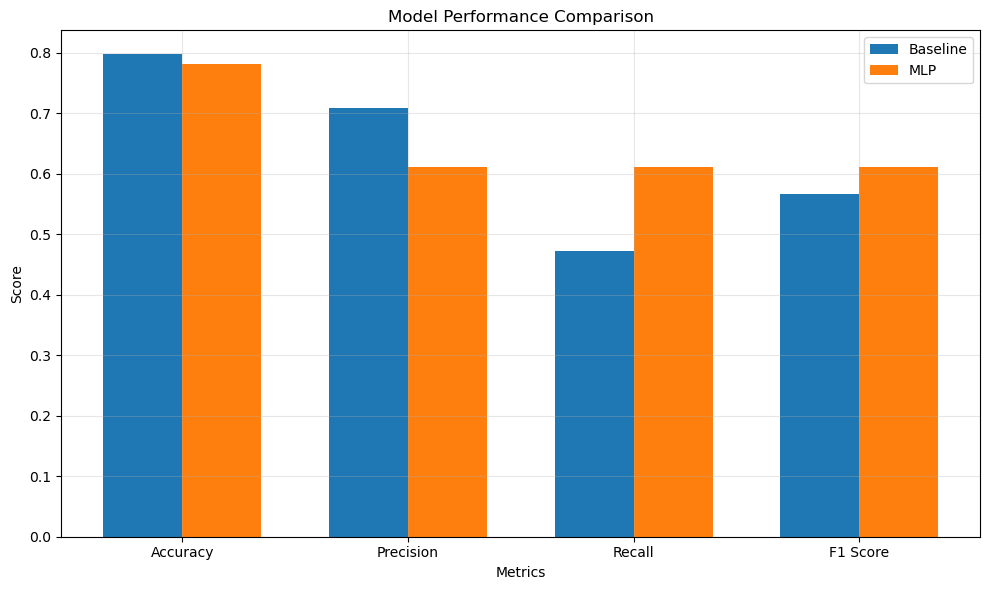

In [23]:
# 2. Performance comparison bar chart
# TODO: Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))

# Example:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
baseline_scores = [baseline_metrics['baseline_model'][m] for m in metrics]
mlp_scores = [mlp_metrics['mlp'][m] for m in metrics]
# 
x = np.arange(len(metrics))
width = 0.35
# 
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [24]:
analysis_text = """
Address these questions:
1. Which model performed better and by how much?
Soln: The baseline Logistic Regression model achieved a higher overall accuracy than the MLP model. However, the MLP achieved a higher recall score. 
This indicates that Logistic Regression made more correct predictions overall, 
while the MLP was better at identifying positive cases.
This indicates that, MLP performed better at the Recall , Recall being our primary Measure.It means that MLP model was Intelligently Able to identify the
features and patterns and it was better model to correctly predict the Positive Cases,then the MLP identified a larger proportion of actual positive samples.

2. Why do you think one model outperformed the other?
Soln: The MLP achieved better recall because it may have learned patterns that helped it identify more positive examples. 
However, this improvement in recall may have come at the cost of more false positives, which can reduce overall accuracy.

3. What was the computational cost difference (training time)?
Soln: The MLP required more training time because it contains multiple layers, weights, and iterative optimization through backpropagation. 
Logistic Regression trained much faster since it has a simpler mathematical structure and fewer parameters to optimize, no of iterations to get the constant loss
for the MLP more, hence this also answeres for it's higher time

4. Any surprising findings or challenges you faced?
Soln: A surprising finding was that the more complex MLP did not outperform Logistic Regression in terms of accuracy. 
This suggests that the dataset may not contain enough non-linear relationships to fully benefit from a neural network.

Another interesting observation was that the MLP achieved higher recall despite lower accuracy. 
This demonstrates that different models can excel on different evaluation metrics, making it important to select metrics based on the problem requirements.

5. What insights did you gain about neural networks vs linear models?
Soln: This experiment showed that a more complex model does not always produce better overall performance. Logistic Regression can provide strong results with lower computational cost and greater interpretability.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 337 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [25]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    
    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """
    
    # Calculate loss convergence flags
    baseline_initial_loss = float(baseline_model.loss_history[0])
    baseline_final_loss = float(baseline_model.loss_history[-1])

    mlp_initial_loss = float(mlp_model.loss_history[0])
    mlp_final_loss = float(mlp_model.loss_history[-1])
    improvement = mlp_metrics["mlp"]["Recall"] - baseline_metrics["baseline_model"]["Recall"]
    baseline = baseline_metrics["baseline_model"]["Recall"]
    improvement_percent = (improvement)/(baseline) * 100
    total_parameters = sum(
    mlp_architecture[i] * mlp_architecture[i + 1] + mlp_architecture[i + 1]
    for i in range(len(mlp_architecture) - 1)
)

    
    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        
        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        
        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.01,
            'n_iterations': 10000,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            
            # Metrics (fill based on your problem type)
            'test_accuracy': 0.796875,      # For classification
            'test_precision': 0.7083333333333334,     # For classification
            'test_recall': 0.4722222222222222,       # For classification
            'test_f1': 0.5666666666666667,            # For classification
        },
        
        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': list(mlp_architecture),
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'total_parameters': total_parameters,     # TODO: Calculate total weights + biases
            'learning_rate': 0.01,
            'n_iterations': 100000,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            
            # Metrics
            'test_accuracy': 0.78125,
            'test_precision': 0.6111111111111112,
            'test_recall': 0.6111111111111112,
            'test_f1': 0.6111111111111112,
        },
        
        # ===== Comparison =====
        'improvement': improvement,
        'improvement_percentage': improvement_percent,
        'baseline_better': False,       # True if baseline outperformed MLP
        
        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        
        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': False,  # Optional: True if converged
        'mlp_converged': False,
    }
    
    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [26]:
# Test the output
import json

try:
    results = get_assignment_results()

    
    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)
    
    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better', 
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")
    
    check_dict(results)
    
    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")
        
except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Pima Indians Diabetes Database",
  "dataset_source": "Kaggle (Pima Indians Diabetes Database, originally from UCI Machine Learning Repository)",
  "n_samples": 768,
  "n_features": 8,
  "problem_type": "binary_classification",
  "problem_statement": "\nPrediciting diabetes or not, this is essential for early detection of diabetes in a patient\n",
  "primary_metric": "recall",
  "metric_justification": "I chose recall because in medical diagnosis,\nfalse negatives (missing diabetes) are more costly than false positives.\"\n",
  "train_samples": 511,
  "test_samples": 127,
  "train_test_ratio": 0.8,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations": 10000,
    "initial_loss": 0.6931471805599453,
    "final_loss": 0.45377490910760476,
    "training_time_seconds": 9.74139928817749,
    "test_accuracy": 0.796875,
    "test_precision": 0.7083333333333334,
    "test_recall": 0.4722222222

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**